In [4]:
#the below is a test, using the first line from the dataset
lines = open("../data/1I_'Oumuamua_obs.txt").read().splitlines()
print(len(lines)) #prints the number of lines (starting at 0)

244


In [5]:
line0 = lines[0]
print(repr(line0)) #The raw line
print("line0 date: ", line0[15:32]) #the date for this line, with the lower number essentially shifted, as python reads differently than humans
print("line0 ra: ", line0[32:44]) #the right ascencion for this line
print("line0 dec: ", line0[44:56]) #the declination for this line
print("line0 obs: ", line0[77:80]) #info abt the observer for this line

'0001IK17U010  C2017 10 14.43936 04 49 12.95 -02 29 47.4          19.0 GU@6548703'
line0 date:  2017 10 14.43936 
line0 ra:  04 49 12.95 
line0 dec:  -02 29 47.4 
line0 obs:  703


In [6]:
import pandas as pd

rows = []
skipped = 0 #this creates a counter for lines we couldn't parse
skipped_pair = 0
for line0 in lines:
    if line0[14].islower(): #any lowercase letter
        skipped_pair += 1
        continue

    #the below is a fix to make the parser detect if there is a shift from an S at the start of the date, from if the observer was a space telescope. This should fix that error.
    off = 0 if line0[15].isdigit() else 1
    rows.append({ #builds a list for the current line of all of its important info (normalizes data)
        "date_str": line0[15+off:32+off].strip(),
        "ra_str":   line0[32+off:44+off].strip(),
        "dec_str":  line0[44+off:56+off].strip(),
        "obscode":  line0[77+off:80+off],
    })

df = pd.DataFrame(rows) #turns the list into a table
print(len(df), "parsed,", skipped, "skipped") #prints how many rows were skipped, and how many made it to the table
df.head() #shows the first five rows of the table

214 parsed, 0 skipped


,date_str,ra_str,dec_str,obscode
0,2017 10 14.43936,04 49 12.95,-02 29 47.4,703
1,2017 10 17.37391,02 36 45.71,+01 06 17.7,703
2,2017 10 18.472979,01 59 57.460,+02 06 04.02,F51
3,2017 10 18.499898,01 59 08.928,+02 07 20.53,F51
4,2017 10 19.397150,01 34 55.364,+02 45 03.09,F51


In [7]:
#This is a validator cell, to ensure that every weird line gets caught before going to the next few cells
looks_ok = df["ra_str"].str.match(r"^\d{2} \d{2} \d{2}") #this line tests every entry in the ra_str column against a pattern, only passing lines that pass the pattern, testing each invididual row. The pattern itself checks to ensure that starting at the very beginning of the string, there are exactly 3 pairs of two digits seperated by spaces.
print((~looks_ok).sum(), "suspicious rows") #the ~ means not, and flips every true to false and visa versa, so looks ok then marks the rows that failed the test, so we know how many failed without creating a new variable. .sum simply counts how many of these failures there are, and the print tells me the quantity
df[~looks_ok].head() #This line prints out the first five rows that didn't pass the test.

0 suspicious rows


,date_str,ra_str,dec_str,obscode


In [8]:
#This column will turn the RA and the Dec into degrees, so they're usable for plotting this data
from astropy.coordinates import SkyCoord #pulls in skyCoord, which is a tool astropy has for representing sky positions
import astropy.units as u #pulling in astropy's system for units (degrees, hours, etc.)

coords = SkyCoord(df["ra_str"], df["dec_str"], unit=(u.hourangle, u.deg)) #feeds the entire RA and Dec columns to SkyCoord at once, and the unit tells it that RA text is in the format of hours-minutes-seconds, while Dec text is in the format of degrees-minutes-seconds
df["ra_deg"] = coords.ra.deg #Creates a new column labeled ra_deg in my table, that contains each RA value now as degrees
df["dec_deg"] = coords.dec.deg #Creates a new column labeled dec_deg in my table, that contains each Dec value now as degrees
df.head() #prints the first five rows, to view the new columns 

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg
0,2017 10 14.43936,04 49 12.95,-02 29 47.4,703,72.303958,-2.496500
1,2017 10 17.37391,02 36 45.71,+01 06 17.7,703,39.190458,1.104917
2,2017 10 18.472979,01 59 57.460,+02 06 04.02,F51,29.989417,2.101117
3,2017 10 18.499898,01 59 08.928,+02 07 20.53,F51,29.787200,2.122369
4,2017 10 19.397150,01 34 55.364,+02 45 03.09,F51,23.730683,2.750858


In [9]:
#this cell should convert the date text into readible simestamps
from datetime import datetime, timedelta #uses python's built in date tools. datetime is for a moment in time, and time delta is for an amount of time

def parse_date(s): #creates a program called parse_date that takes a text date and returns a timestamp
    y, m, d = s.split() #splits our text into three peices, year, m onth, and day (fraction of a day)
    day_frac = float(d) #converts the text for the day (ex. 08.51765) into a number
    day = int(day_frac) #keeps the whole number part, and seperates the fraction
    frac = day_frac - day #converts the leftover decimal into the fraction of the day that had passed (ex. 0.41196 to abt 9.9 hrs)
    return datetime(int(y), int(m), day) + timedelta(days=frac) #adds the fraction as actual hours.minutes, returns the completed timestamp

df["time"] = df["date_str"].apply(parse_date) # runs the program on every entry within the date_str column in the dataset, and stores the results in a new column it created, time.
df.head() #prints the timestamps for the first 5 rows of the dataset

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg,time
0,2017 10 14.43936,04 49 12.95,-02 29 47.4,703,72.303958,-2.496500,2017-10-14 10:32:40.704000
1,2017 10 17.37391,02 36 45.71,+01 06 17.7,703,39.190458,1.104917,2017-10-17 08:58:25.824000
2,2017 10 18.472979,01 59 57.460,+02 06 04.02,F51,29.989417,2.101117,2017-10-18 11:21:05.385600
3,2017 10 18.499898,01 59 08.928,+02 07 20.53,F51,29.787200,2.122369,2017-10-18 11:59:51.187200
4,2017 10 19.397150,01 34 55.364,+02 45 03.09,F51,23.730683,2.750858,2017-10-19 09:31:53.760000


In [10]:
#This cell should administer sanity checks
print("total observations:", len(df)) #len(df) is the number of rows on our table, equilivent to the observations parsed
print("first:", df["time"].min()) #prints out the earliest timesteamp in the time column
print("last: ", df["time"].max()) #prints out the latest timestamp in the time column
print(df["obscode"].value_counts().head(10)) #counts how many times each different observatory code appears, sorted from largest to smallest, and shows the top 10

total observations: 214
first: 2017-10-14 10:32:40.704000
last:  2018-01-02 11:28:28.531200
obscode
250    30
568    27
H01    22
926    16
309     9
G37     9
304     9
G96     8
950     8
K93     8
Name: count, dtype: int64


In [11]:
#quantifies the entries from TESS
sat = df[df["obscode"] == "C57"]
print(len(sat), sat["time"].min())

0 NaT


In [12]:
#This cell sorts our table by time, preparing it for being graphed.
df = df.sort_values("time")
df.tail(3)

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg,time
211,2018 01 02.465585,23 31 53.329,+09 17 13.56,250,352.972204,9.287100,2018-01-02 11:10:26.544000
212,2018 01 02.471847,23 31 53.435,+09 17 15.72,250,352.972646,9.287700,2018-01-02 11:19:27.580800
213,2018 01 02.478108,23 31 53.570,+09 17 17.23,250,352.973208,9.288119,2018-01-02 11:28:28.531200


In [13]:
#This cell will be a true/False mask, with the same pattern as the validator I built earlier
outliers = (df["dec_deg"] > 25) | (df["ra_deg"] > 320) #This lists two conditions, that either the Dec was above 25, or the RA was above 320, joined by or, thresholds coming from simply eyeballing the graph, as no legitemente data should be in this area at all. Note: outliers is in true/false form per row
print(outliers.sum(), "outliers") #counts the quantity of outliers and prints them
df[outliers][["time", "ra_deg", "dec_deg", "obscode"]] #this line shows the flagged rows, but only the four columns I care about from those rows, so I can see exactly when they happened and who subimmited them. 

115 outliers


,time,ra_deg,dec_deg,obscode
99,2017-10-27 03:07:50.016000,359.758708,4.960722,850
100,2017-10-27 03:31:42.528000,359.733792,4.962972,850
101,2017-10-27 03:55:54.048000,359.709000,4.964500,850
102,2017-10-27 05:11:27.456000,359.632375,4.971083,850
103,2017-10-27 05:57:32.256000,359.586375,4.975472,850
...,...,...,...,...
209,2018-01-02 10:52:24.556800,352.971046,9.285583,250
210,2018-01-02 11:01:25.593600,352.971721,9.286367,250
211,2018-01-02 11:10:26.544000,352.972204,9.287100,250
212,2018-01-02 11:19:27.580800,352.972646,9.287700,250


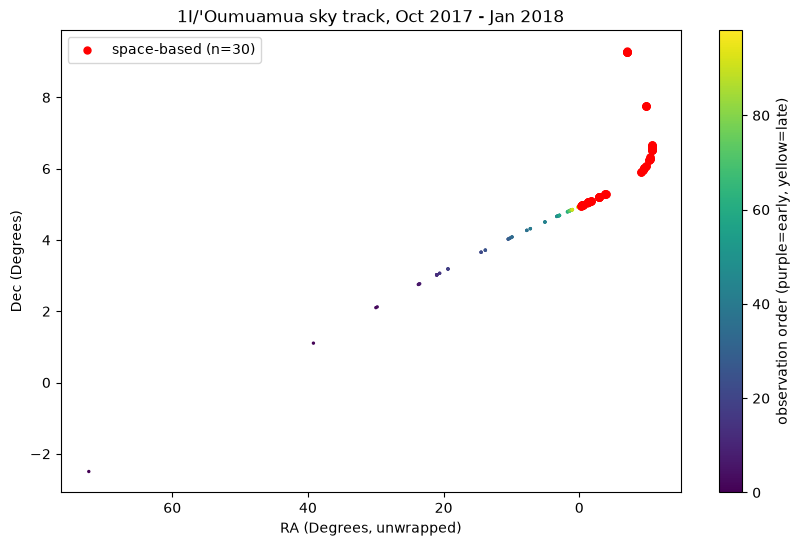

In [ ]:
#This will create a plot of the skytrack of 1I/'Oumuamua throughout all of its available observations
#Comments may be outdated

import matplotlib.pyplot as plt

space_codes = ("250",) #what the census actually found
bad = df["obscode"].isin(space_codes) #if it's a spacecraft, it says that in the records
clean = df[~outliers]
sp = df[outliers]

ra_c = clean["ra_deg"].where(clean["ra_deg"] < 180, clean["ra_deg"] - 360)
ra_s = sp["ra_deg"].where(sp["ra_deg"] < 180, sp["ra_deg"] - 360)

plt.figure(figsize=(10, 6)) #Creates a new blank figure/plot, 10x6 inches
plt.scatter(ra_c, clean["dec_deg"], c=range(len(clean)), cmap="viridis", s=2) #plots all of the "clean" datapoints with the normal color scheme
plt.colorbar(label="observation order (purple=early, yellow=late)") #adds the color legend so that you can actually understand how it relates to time
plt.scatter(ra_s, sp["dec_deg"], color="red", s=25, label=f"space-based (n={bad.sum()})") #Colors the outliers red, and gives them a label for the legend
plt.legend() #Creates a legend
plt.xlabel("RA (Degrees, unwrapped)") #Label for the x-axis
plt.ylabel("Dec (Degrees)") #Label for the y-axis
plt.title("1I/'Oumuamua sky track, Oct 2017 - Jan 2018") #Titel for the plot
plt.gca().invert_xaxis() #inverts the x-axis
#plt.savefig("../figures/1I_'Oumuamua.png", dpi=150) #saves this to the figures folder as a png file
plt.show()

In [ ]:
#This cell will allow me to cut down the dataset side, to hopefully be able to use Find_Orb on this data
#comments may be outdated because of rapid iteration

sub = []
keep_codes = ("336", "338", "339")
for i, line in enumerate(lines): #parses through all of the lines, while simultaniously giving them to me
    if len(line) >= 80 and line[14].islower(): #if this program happened to land on a "continuation" line, with a lowercase letter at index 14, it would skip it, as these lines come in pairs, and one wihtout the other is not useful.
        continue
    is_craft = len(line) >= 80 and line[77:80] in keep_codes
    if not (is_craft or i % 10 == 0):
        continue
    sub.append(line) #if it passed the test, and does not have a continuation line, it'll keep it in the list
    if i + 1 < len(lines) and len(lines[i+1]) >= 80 and lines[i+1][14].islower(): #will look at the line after the primary one we're observing. If it is a continuation line, we take the line after it with us, because we want the pairs to come together. 
        sub.append(lines[i+1])

#open("../data/3I_sub.txtV3", "w").write("\n".join(sub)) #puts all of the kept lines together with line breaks, and puts them into a new file
print(len(sub), "lines written") #pastes out the number of lines written.
print(sum(1 for l in sub if len(l) >= 80 and l[77:80] in keep_codes), "spacecraft obs kept (9 are expected)")